In [1]:
import os
import glob
import json
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import fn.network_builder as build
import fn.node_collect as nc
import fn.edge_collect as ec

In [2]:
class GraphExtractor:
    def __init__(self, output_dir="results", save_fig=False, img_dpi=300):
        self.output_dir = output_dir
        self.save_fig = save_fig
        self.img_dpi = img_dpi
        self._ensure_dirs()

    def _ensure_dirs(self):
        sub = ["mask_and_skeleton", "structure_and_order", "node_and_edge", "path_list", "graph_json"]
        for s in sub:
            os.makedirs(os.path.join(self.output_dir, s), exist_ok=True)

    def _basename(self, path):
        return os.path.splitext(os.path.basename(path))[0]

    def _json_path(self, base):
        return os.path.join(self.output_dir, "graph_json", f"{base}.json")

    @staticmethod
    def _clean_json(obj):
        if isinstance(obj, dict):
            return {k: GraphExtractor._clean_json(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [GraphExtractor._clean_json(v) for v in obj]
        if isinstance(obj, (set, tuple)):
            return [GraphExtractor._clean_json(v) for v in obj]
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return GraphExtractor._clean_json(obj.tolist())
        return obj

    def process_folder(self, folder):
        img_paths = sorted(glob.glob(os.path.join(folder, "*.png")))
        for p in img_paths:
            self.process_image(p)

    def process_image(self, img_path):
        base = self._basename(img_path)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, img = cv2.threshold(img, 1, 255, cv2.THRESH_BINARY)
        img = 1 - (img / 255)
        np.save(os.path.join(self.output_dir, "mask_and_skeleton", f"{base}.npy"), img)
        thin = build.segment_thin.zhangSuen(img)
        if self.save_fig:
            plt.imshow(thin)
            plt.axis("off")
            plt.savefig(os.path.join(self.output_dir, "mask_and_skeleton", f"skeleton_vis_{base}.png"),
                        dpi=self.img_dpi, bbox_inches="tight")
            plt.close()
        np.save(os.path.join(self.output_dir, "mask_and_skeleton", f"skeleton_{base}.npy"), thin)
        st = nc.get_structure(np.sign(thin).astype(int))
        np.save(os.path.join(self.output_dir, "structure_and_order", f"structure_and_order_{base}.npy"), st)
        node_proc = nc.network_node_refine(
            structure=os.path.join(self.output_dir, "structure_and_order", f"structure_and_order_{base}.npy"),
            skeleton=os.path.join(self.output_dir, "mask_and_skeleton", f"skeleton_{base}.npy"),
            shape=thin.shape
        )
        _ = node_proc.find_node()
        node_list = node_proc.node_list_refine()
        con_list, _ = node_proc.connection_refine(node_list, return_dict=True)
        np.save(os.path.join(self.output_dir, "node_and_edge", f"node_list_{base}.npy"), node_list)
        np.save(os.path.join(self.output_dir, "node_and_edge", f"con_list_{base}.npy"), con_list)
        edge_proc = ec.network_edge_refine(node_list=node_list, connection=con_list)
        edge_proc.find_initPaths()
        np.save(os.path.join(self.output_dir, "path_list", f"path_list_{base}.npy"), edge_proc.initPaths)
        simple = ec.edge_opt(node_list=node_list, path_list=edge_proc.initPaths)
        simple.opt_redundantNode()
        branch_nodes = ec.edge_merge.degree_check(
            full_graph=edge_proc.fullPathGraph,
            simple_graph=simple.Graph,
            bunch=simple.true_node_index
        )
        removed = ec.edge_merge.branch_opt(
            branch_nodes=simple.true_node_index,
            full_graph=edge_proc.fullPathGraph,
            simple_graph=simple.Graph
        )
        simple.remove_edges(remove=removed)
        fullGraph = edge_proc.load_fullPathGraph()
        if self.save_fig:
            plt.figure(figsize=(10, 10), dpi=self.img_dpi)
            nx.draw_networkx_nodes(fullGraph, edge_proc.npos, nodelist=edge_proc.true_node_index,
                                   node_size=10, node_color="maroon")
            nx.draw_networkx_edges(fullGraph, edge_proc.npos, edgelist=fullGraph.edges(),
                                   edge_color="lightblue", width=3)
            plt.gca().invert_yaxis()
            plt.axis("off")
            plt.savefig(os.path.join(self.output_dir, "path_list", f"fullNet_{base}.png"),
                        dpi=self.img_dpi, bbox_inches="tight")
            plt.close()
        for n in simple.Graph.nodes:
            y, x = edge_proc.npos[n]
            simple.Graph.nodes[n]["x"] = float(x)
            simple.Graph.nodes[n]["y"] = float(y)
        data = nx.readwrite.json_graph.node_link_data(simple.Graph)
        data = self._clean_json(data)
        with open(self._json_path(base), "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False)
        xs = [simple.Graph.nodes[n]["x"] for n in simple.Graph.nodes]
        ys = [simple.Graph.nodes[n]["y"] for n in simple.Graph.nodes]
        print(f"{base}: nodes={simple.Graph.number_of_nodes()}, edges={simple.Graph.number_of_edges()}, "
              f"x[{min(xs):.1f},{max(xs):.1f}], y[{min(ys):.1f},{max(ys):.1f}]")

if __name__ == "__main__":
    extractor = GraphExtractor(output_dir="ZYY_260408_AFM", save_fig=True)
    extractor.process_folder("ZYY_260408_AFM")#####

Total nodes: 1087


Processing nodes: 100%|██████████| 1086/1086 [34:09<00:00,  1.89s/it] 


507 / 1087 nodes were removed during opt_redundantNode
1371 / 2255 edges were removed during opt_redundantNode
131 / 884 branch edges removed
260408_Fix_by_yh: nodes=580, edges=884, x[0.0,495.0], y[0.0,499.0]


In [3]:

import fn.edge_collect as ec
import os, glob, numpy as np, networkx as nx, matplotlib.pyplot as plt
from pathlib import Path

RES_DIR   = "ZYY_260408_AFM"#####
NODE_DIR  = f"{RES_DIR}/node_and_edge"
PATH_DIR  = f"{RES_DIR}/path_list"

def draw_simple(base, dpi=300):
    node_list = np.load(f"{NODE_DIR}/node_list_{base}.npy", allow_pickle=True)
    con_list  = np.load(f"{NODE_DIR}/con_list_{base}.npy",  allow_pickle=True)

    img = ec.network_edge_refine(node_list=node_list, connection=con_list)

    pfile = f"{PATH_DIR}/path_list_{base}.npy"
    if os.path.exists(pfile):
        img.initPaths = np.load(pfile, allow_pickle=True)
    else:
        img.find_initPaths()
        np.save(pfile, img.initPaths)

    img_s = ec.edge_opt(node_list=node_list, path_list=img.initPaths)
    img_s.opt_redundantNode()
    rm = ec.edge_merge.branch_opt(
            branch_nodes = img_s.true_node_index,
            full_graph   = img.fullPathGraph,
            simple_graph = img_s.Graph)
    img_s.remove_edges(remove=rm)

    sGraph = img_s.load_Graph()

    plt.figure(figsize=(10,10), dpi=dpi)
    nx.draw_networkx_edges(img.fullPathGraph, img.npos,
                           edgelist=img.fullPathGraph.edges(),
                           edge_color="lightblue", width=3)
    nx.draw_networkx_edges(sGraph, img.npos,
                           edgelist=sGraph.edges(),
                           edge_color="purple", width=2)
    nx.draw_networkx_nodes(sGraph, img.npos,
                           nodelist=img_s.true_node_index,
                           node_color="purple", node_size=1)
    plt.gca().invert_yaxis(); plt.axis("off")
    out_png = f"{PATH_DIR}/simpleNet_{base}.png"
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close()
    print("✓", out_png)

# 找到已有 fullNet 但还没画 simpleNet 的样本
full_set   = {Path(p).stem.replace("fullNet_",   "") for p in glob.glob(f"{PATH_DIR}/fullNet_*.png")}
simple_set = {Path(p).stem.replace("simpleNet_", "") for p in glob.glob(f"{PATH_DIR}/simpleNet_*.png")}
todo = sorted(full_set - simple_set)

print("待补 simpleNet 数量:", len(todo))
for b in todo:
    draw_simple(b)

待补 simpleNet 数量: 1
507 / 1087 nodes were removed during opt_redundantNode
1371 / 2255 edges were removed during opt_redundantNode
131 / 884 branch edges removed
✓ ZYY_260408_AFM/path_list/simpleNet_260408_Fix_by_yh.png


In [5]:
import os, re, glob, json, math, numpy as np
import networkx as nx, pandas as pd, scipy.stats as st

def orientation_metrics(G):
    dx_sum, dy_sum, angles = 0.0, 0.0, []
    for u, v in G.edges():
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        dx, dy = abs(x2 - x1), abs(y2 - y1)
        if dx == dy == 0:   # 重合节点
            continue
        dx_sum += dx
        dy_sum += dy
        angles.append(math.degrees(math.atan2(dy, dx)))
    if not angles:
        return 0, 0, 0
    return np.mean(angles), np.std(angles), (dx_sum / dy_sum) if dy_sum else np.inf

def fractal_dimension(points, min_box=2, max_box=128, num_scales=10):
    sizes = np.logspace(math.log10(min_box), math.log10(max_box), num=num_scales, dtype=int)
    sizes = np.unique(sizes)
    if len(sizes) < 2:
        return 0
    counts = []
    pts = np.array(points)
    for s in sizes:
        bins = ((pts - pts.min(axis=0)) // s).astype(int)
        h = set(map(tuple, bins))
        counts.append(len(h))
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

files = glob.glob('ZYY_260408_AFM/graph_json/*.json')########################
pattern = re.compile(r'.+\.json$')
rows = []

for f in files:
    if not pattern.match(os.path.basename(f)):
        continue
    with open(f, encoding='utf-8') as fp:
        data = json.load(fp)
    G = nx.readwrite.json_graph.node_link_graph(data)

    props = {}
    props['file'] = os.path.basename(f)
    props['nodes'] = G.number_of_nodes()
    props['edges'] = G.number_of_edges()
    deg = [d for _, d in G.degree()]
    props['avg_degree'] = sum(deg) / len(deg) if deg else 0
    props['density'] = nx.density(G)
    props['avg_clustering'] = nx.average_clustering(G)

    if G.number_of_nodes() > 1:
        H = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len)).copy()
        props['diameter'] = nx.diameter(H)
        props['avg_path_length'] = nx.average_shortest_path_length(H)
    else:
        props['diameter'] = 0
        props['avg_path_length'] = 0

    try:
        props['assortativity'] = nx.degree_pearson_correlation_coefficient(G)
    except nx.NetworkXError:
        props['assortativity'] = float('nan')

    om, osd, ratio = orientation_metrics(G)
    props['orient_mean_deg'] = om
    props['orient_std_deg'] = osd
    props['orientation_ratio'] = ratio

    pts = [(n['x'], n['y']) for _, n in G.nodes(data=True)]
    props['fractal_dim'] = fractal_dimension(pts)

    rows.append(props)

df = pd.DataFrame(rows)
df.to_csv('ZYY_260408_AFM/graph_metrics.csv', index=False)############
df

,file,nodes,edges,avg_degree,density,avg_clustering,diameter,avg_path_length,assortativity,orient_mean_deg,orient_std_deg,orientation_ratio,fractal_dim
0,260408_Fix_by_yh.json,580,884,3.048276,0.005265,0.19947,41,15.737716,0.3078,44.954579,26.341153,1.047689,0.808244


#

In [14]:
import os, re, glob, json, math, numpy as np
import networkx as nx, pandas as pd, scipy.stats as st
from collections import Counter

def orientation_metrics(G):
    dx_sum, dy_sum, angles = 0.0, 0.0, []
    for u, v in G.edges():
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        dx, dy = abs(x2 - x1), abs(y2 - y1)
        if dx == dy == 0:
            continue
        dx_sum += dx
        dy_sum += dy
        angles.append(math.degrees(math.atan2(dy, dx)))
    if not angles:
        return 0, 0, 0
    return np.mean(angles), np.std(angles), (dx_sum / dy_sum) if dy_sum else np.inf

def fractal_dimension(points, min_box=2, max_box=128, num_scales=10):
    sizes = np.logspace(math.log10(min_box), math.log10(max_box), num=num_scales, dtype=int)
    sizes = np.unique(sizes)
    if len(sizes) < 2:
        return 0
    counts = []
    pts = np.array(points)
    for s in sizes:
        bins = ((pts - pts.min(axis=0)) // s).astype(int)
        h = set(map(tuple, bins))
        counts.append(len(h))
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    return -coeffs[0]

files = glob.glob('251203_whitemoth_result/graph_json/*.json')
pattern = re.compile(r'.+\.json$')
rows = []

for f in files:
    if not pattern.match(os.path.basename(f)):
        continue
    with open(f, encoding='utf-8') as fp:
        data = json.load(fp)
    G = nx.readwrite.json_graph.node_link_graph(data)

    props = {}
    props['file'] = os.path.basename(f)
    props['nodes'] = G.number_of_nodes()
    props['edges'] = G.number_of_edges()
    deg = [d for _, d in G.degree()]
    deg_freq = Counter(deg)
    print(f"{os.path.basename(f)} degree distribution: {dict(sorted(deg_freq.items()))}")
    props['avg_degree'] = sum(deg) / len(deg) if deg else 0
    props['density'] = nx.density(G)
    props['avg_clustering'] = nx.average_clustering(G)

    if G.number_of_nodes() > 1:
        H = G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G), key=len)).copy()
        props['diameter'] = nx.diameter(H)
        props['avg_path_length'] = nx.average_shortest_path_length(H)
    else:
        props['diameter'] = 0
        props['avg_path_length'] = 0

    try:
        props['assortativity'] = nx.degree_pearson_correlation_coefficient(G)
    except nx.NetworkXError:
        props['assortativity'] = float('nan')

    om, osd, ratio = orientation_metrics(G)
    props['orient_mean_deg'] = om
    props['orient_std_deg'] = osd
    props['orientation_ratio'] = ratio

    pts = [(n['x'], n['y']) for _, n in G.nodes(data=True)]
    props['fractal_dim'] = fractal_dimension(pts)

    rows.append(props)

df = pd.DataFrame(rows)
df.to_csv('Pengrx_filaria_gland_AFM_result/graph_metrics.csv', index=False)
print(df)

Empty DataFrame
Columns: []
Index: []


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
# ------------------------------------------------
#  两套目录 → 指标 CSV → 绘图(蓝点+金线) → 对比 CSV
#  mesh_size 采用图像学算法
# ------------------------------------------------
import os, re, glob, json, math, numpy as np, networkx as nx, pandas as pd
import matplotlib.pyplot as plt; from skimage import io; from scipy.ndimage import label
plt.style.use('seaborn-v0_8-ticks')

PROJECTS = [r"E:\AI_F\normalize\results_normalization",
            r"E:\AI_F\normalize\results_MD_normalization"]
IMG_DIRS  = {'results_normalization'    : r"E:\AI_F\normalize\image_normalization",
             'results_MD_normalization': r"E:\AI_F\normalize\images_MD_normalization"}

# ---------- 工具函数 ----------
_suffix_pat = re.compile(r'_(\d+)\.json$').search
def suffix_num(f):            # 提取序号
    m=_suffix_pat(f); return int(m.group(1)) if m else -1

def orientation_metrics(G):   # 平均角度 与 dx/dy
    dx=dy=0.; ang=[]
    for u,v in G.edges():
        x1,y1,x2,y2=*(G.nodes[u][k] for k in('x','y')),*(G.nodes[v][k] for k in('x','y'))
        dxx,dyy=abs(x2-x1),abs(y2-y1)
        if dxx==dyy==0: continue
        dx+=dxx; dy+=dyy; ang.append(math.degrees(math.atan2(dyy,dxx)))
    return (np.mean(ang) if ang else 0., dx/dy if dy else np.inf)

def mesh_size_img(png):       # 图像法孔径
    img=io.imread(png,as_gray=True); img=(img*255).astype('u1') if img.max()<=1 else img
    rows=np.where((img<128).mean(1)>0.02)[0]; core=img[rows[0]:rows[-1]+1] if rows.size else img
    lbl,n=label(core>=128); keep=np.ones(n+1,bool); keep[0]=False
    keep[np.unique(np.r_[lbl[0],lbl[-1],lbl[:,0],lbl[:,-1]])]=False
    diam=[2*math.sqrt(((lbl==i).sum())/math.pi) for i in range(1,n+1) if keep[i]]
    return float(np.median(diam)) if diam else np.nan

def rpgc_fraction(G,tol=0.1): # 刚性巨分支占比
    l=[math.hypot(G.nodes[u]['x']-G.nodes[v]['x'],G.nodes[u]['y']-G.nodes[v]['y']) for u,v in G.edges()]
    if not l: return 0.
    med=np.median(l); rig=[e for e,ll in zip(G.edges(),l) if abs(ll-med)/med<=tol]
    return len(max(nx.connected_components(G.edge_subgraph(rig)),key=len))/G.number_of_nodes() if rig else 0.

def fractal_dimension(pts,mb=2,xb=128,k=10): # 盒计数维
    s=np.unique(np.logspace(math.log10(mb),math.log10(xb),k,dtype=int)); pts=np.array(pts)
    if s.size<2: return 0.
    cnt=[len(set(map(tuple,((pts-pts.min(0))//i).astype(int)))) for i in s]
    return -float(np.polyfit(np.log(s),np.log(cnt),1)[0])

def algebraic_conn(G):        # 代数连通度
    return float(nx.algebraic_connectivity(G)) if G.number_of_nodes()>1 and nx.is_connected(G) else 0.

# ---------- 主流程 ----------
metrics=['nodes_change','edges_change','total_length','density_change','length_change','diameter_change',
         'alg_connect','orient_mean_deg','orientation_ratio','mesh_size','rpgc_fraction','fractal_dim']
project_means={}

for base in PROJECTS:
    img_dir=IMG_DIRS[os.path.basename(base)]
    rows=[]
    for fp in glob.glob(os.path.join(base,'graph_json','*.json')):
        with open(fp) as f: G=nx.readwrite.json_graph.node_link_graph(json.load(f))
        p={'file':os.path.basename(fp),
           'nodes_raw':G.number_of_nodes(),
           'edges_raw':G.number_of_edges(),
           'total_length':sum(math.hypot(G.nodes[u]['x']-G.nodes[v]['x'],
                                         G.nodes[u]['y']-G.nodes[v]['y']) for u,v in G.edges()),
           'density_raw':nx.density(G)}
        H=G if nx.is_connected(G) else G.subgraph(max(nx.connected_components(G),key=len)).copy() if G.number_of_nodes()>1 else None
        p['spath_raw']=nx.average_shortest_path_length(H) if H else 0.; p['diameter_raw']=nx.diameter(H) if H else 0.
        om,rt=orientation_metrics(G); p['orient_mean_deg']=om; p['orientation_ratio']=rt
        png=os.path.join(img_dir,p['file'].replace('.json','.png')); p['mesh_size']=mesh_size_img(png)
        p['rpgc_fraction']=rpgc_fraction(G); p['alg_connect']=algebraic_conn(G)
        p['fractal_dim']=fractal_dimension([(d['x'],d['y']) for _,d in G.nodes(data=True)])
        p['suffix']=suffix_num(p['file']); rows.append(p)

    df=pd.DataFrame(rows); base_row=df.loc[df['suffix'].idxmin()]
    for k in ('nodes','edges','density','spath','diameter'):
        df[f'{k}_change']=(df[f'{k}_raw']-base_row[f'{k}_raw']).abs()
    df.rename(columns={'spath_change':'length_change'},inplace=True)
    df.drop(columns=[c for c in df.columns if c.endswith('_raw')],inplace=True)
    df.to_csv(os.path.join(base,'graph_metrics.csv'),index=False)

    # ---- 分组均值 & 平滑 ----
    mean_df=df.groupby('suffix',as_index=False)[metrics].mean().sort_values('suffix').reset_index(drop=True)
    mean_df.insert(0,'step',mean_df.index)
    sm=mean_df[metrics].rolling(3,center=True,min_periods=1).mean()
    for m in metrics: mean_df[f'{m}_smooth']=sm[m]
    project_means[os.path.basename(base)]=mean_df

    # ---- 绘图 ----
    n_rows=math.ceil(len(metrics)/4); fig,axs=plt.subplots(n_rows,4,figsize=(4.8*4,3.8*n_rows),constrained_layout=True)
    for ax,m in zip(axs.ravel(),metrics):
        ax.plot(mean_df['step'],mean_df[m],'o-',color='tab:blue',label='mean')
        ax.plot(mean_df['step'],mean_df[f'{m}_smooth'],'-',color='gold',lw=2,label='smooth')
        ax.set_title(m,fontsize=9); ax.grid(ls=':',lw=0.5); ax.legend(fontsize=7)
    for ax in axs.ravel()[len(metrics):]: fig.delaxes(ax)
    fig.savefig(os.path.join(base,'metrics_overview.png'),dpi=300); plt.close(fig)
    print(f'Overview figure saved to {os.path.basename(base)}')

# ---------- 对比 CSV ----------
cmp_dir='comparison_csv'; os.makedirs(cmp_dir,exist_ok=True)
k0,k1=list(project_means.keys())
for m in metrics:
    a=project_means[k0][['step',m,f'{m}_smooth']].rename(columns={m:k0,f'{m}_smooth':f'{k0}_smooth'})
    b=project_means[k1][['step',m,f'{m}_smooth']].rename(columns={m:k1,f'{m}_smooth':f'{k1}_smooth'})
    pd.merge(a,b,on='step').to_csv(os.path.join(cmp_dir,f'{m}_compare.csv'),index=False)
print('All comparison CSV saved to',cmp_dir)

Overview figure saved to results_normalization
Overview figure saved to results_MD_normalization
All comparison CSV saved to comparison_csv


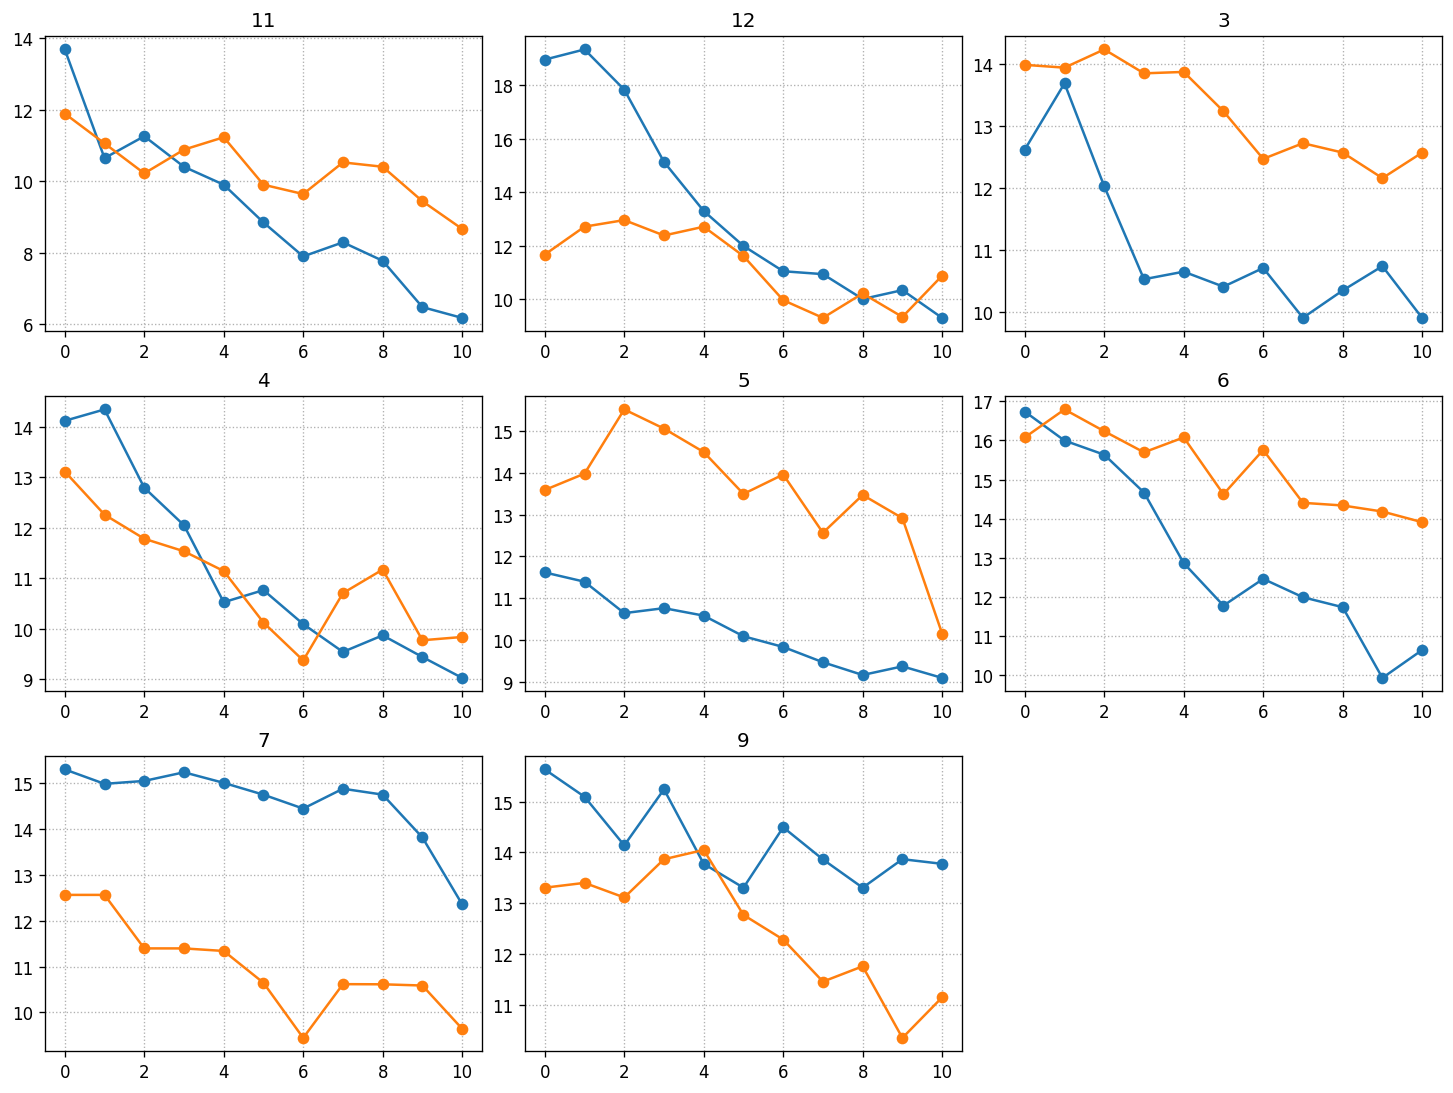

  sample  n_pts  pearson_r      rmse
0      6     11   0.868924  2.576829
1      4     11   0.861553  1.033562
2     11     11   0.851665  1.844171
3     12     11   0.746453  3.521422
4      7     11   0.660646  3.696504
5      3     11   0.640544  2.360025
6      5     11   0.605283  3.544708
7      9     11   0.497597  2.002140


In [4]:
import re, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

CSV_A = r"E:\AI_F\normalize\results_normalization\graph_metrics.csv"
CSV_B = r"E:\AI_F\normalize\results_MD_normalization\graph_metrics.csv"
OUT_DETAIL  = "mesh_size_pair_detail.csv"
OUT_SUMMARY = "mesh_size_pair_similarity.csv"

def nkey(s):
    return tuple(int(t) if t.isdigit() else t.lower()
                 for t in re.split(r'(\d+)', s))

def load(path):
    df = pd.read_csv(path, usecols=["file", "mesh_size"])
    df["sample"] = df["file"].str.extract(r'^([^_]+)')
    df = df.sort_values(["sample", "file"], key=lambda c: c.map(nkey))
    df["order"] = df.groupby("sample").cumcount()
    return df

a = load(CSV_A).rename(columns={"file":"file_A","mesh_size":"mesh_A"})
b = load(CSV_B).rename(columns={"file":"file_B","mesh_size":"mesh_B"})

merged = pd.merge(a, b, on=["sample", "order"], how="inner")
merged["diff"] = merged.mesh_B - merged.mesh_A

rows = []
for s, g in merged.groupby("sample"):
    x, y = g.mesh_A.values, g.mesh_B.values
    r = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
    rmse = math.sqrt(np.mean((x - y) ** 2))
    rows.append((s, len(x), r, rmse))
summary = (pd.DataFrame(rows, columns=["sample","n_pts","pearson_r","rmse"])
             .sort_values("pearson_r", ascending=False)
             .reset_index(drop=True))

n = len(summary)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), constrained_layout=True)
for ax, (s, g) in zip(axes.ravel(), merged.groupby("sample")):
    ax.plot(g.order, g.mesh_A, "o-", label="A")
    ax.plot(g.order, g.mesh_B, "o-", label="B")
    ax.set_title(s); ax.grid(ls=":")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.show()

print(summary)

merged.to_csv(OUT_DETAIL, index=False)
summary.to_csv(OUT_SUMMARY, index=False)

In [5]:
import re, math, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
plt.rcParams["figure.dpi"] = 120

CSV_A = r"E:\AI_F\normalize\results_normalization\graph_metrics.csv"
CSV_B = r"E:\AI_F\normalize\results_MD_normalization\graph_metrics.csv"

DIR_RAW    = Path("plots_raw");    DIR_RAW.mkdir(exist_ok=True)
DIR_SMOOTH = Path("plots_smooth"); DIR_SMOOTH.mkdir(exist_ok=True)

DETAIL_CSV  = "mesh_size_pair_detail.csv"
SUMMARY_CSV = "mesh_size_pair_similarity.csv"

def nkey(name: str):
    return tuple(int(t) if t.isdigit() else t.lower()
                 for t in re.split(r'(\d+)', name))

def load(path: str):
    df = pd.read_csv(path, usecols=["file", "mesh_size"])
    df["sample_id"] = df["file"].str.extract(r'^([^_]+)')  # 样品编号
    df = df.sort_values(["sample_id", "file"], key=lambda c: c.map(nkey))
    df["order"] = df.groupby("sample_id").cumcount()
    return df

a = load(CSV_A).rename(columns={"file": "file_A", "mesh_size": "mesh_A"})
b = load(CSV_B).rename(columns={"file": "file_B", "mesh_size": "mesh_B"})

merged = pd.merge(a, b, on=["sample_id", "order"], how="inner")
merged["diff"] = merged.mesh_B - merged.mesh_A
merged.to_csv(DETAIL_CSV, index=False)

# ------ Savitzky-Golay 平滑 -------------------------------------------------
def smooth(arr: np.ndarray):
    n = len(arr)
    if n < 5:
        return arr
    win = n if n % 2 else n - 1      # window_length 必须是奇数
    win = min(win, 11)               # 控制在 11 以内
    return savgol_filter(arr, window_length=win, polyorder=2)

smoothed = (
    merged.groupby("sample_id", sort=False)
          .apply(lambda g: pd.DataFrame({
              "sample_id": g["sample_id"].values,
              "order":     g["order"].values,
              "mesh_A_s":  smooth(g.mesh_A.values),
              "mesh_B_s":  smooth(g.mesh_B.values)
          }))
          .reset_index(drop=True)
)
smoothed.to_csv("mesh_size_pair_smooth.csv", index=False)
# ------ 相似度指标 ---------------------------------------------------------
summary = (
    merged.groupby("sample_id", sort=False)
          .apply(lambda g: pd.Series({
              "n_pts":     len(g),
              "pearson_r": np.corrcoef(g.mesh_A, g.mesh_B)[0, 1]
                           if len(g) > 1 else np.nan,
              "rmse":      math.sqrt(np.mean((g.mesh_B - g.mesh_A) ** 2))
          }))
          .reset_index()
          .sort_values("pearson_r", ascending=False, ignore_index=True)
)
summary.to_csv(SUMMARY_CSV, index=False)

# ------ 绘图 ---------------------------------------------------------------
def save_single(raw_df, smooth_df, sid):
    # 原始
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(raw_df.order, raw_df.mesh_A, "o-", label="A")
    ax.plot(raw_df.order, raw_df.mesh_B, "o-", label="B")
    ax.set_title(f"{sid} raw"); ax.grid(ls=":"); ax.legend(fontsize=8)
    fig.savefig(DIR_RAW / f"{sid}_raw.png"); plt.close(fig)
    # 平滑
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(smooth_df.order, smooth_df.mesh_A_s, "-", label="A_s")
    ax.plot(smooth_df.order, smooth_df.mesh_B_s, "-", label="B_s")
    ax.set_title(f"{sid} smooth"); ax.grid(ls=":"); ax.legend(fontsize=8)
    fig.savefig(DIR_SMOOTH / f"{sid}_smooth.png"); plt.close(fig)

for sid in merged["sample_id"].unique():
    save_single(merged[merged["sample_id"] == sid],
                smoothed[smoothed["sample_id"] == sid], sid)

def grid_plot(df, cols, path, title):
    n = df["sample_id"].nunique(); ncols = 3; nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3 * nrows),
                             constrained_layout=True)
    for ax, (sid, g) in zip(axes.ravel(), df.groupby("sample_id", sort=False)):
        ax.plot(g.order, g[cols[0]], label=cols[0])
        ax.plot(g.order, g[cols[1]], label=cols[1])
        ax.set_title(sid); ax.grid(ls=":")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle(title)
    fig.savefig(path); plt.close(fig)

grid_plot(merged,   ["mesh_A",   "mesh_B"],   DIR_RAW   / "grid_raw.png",   "Raw curves")
grid_plot(smoothed, ["mesh_A_s", "mesh_B_s"], DIR_SMOOTH/ "grid_smooth.png","Smoothed curves")

print("前 10 相似度：")
print(summary.head(10))
print("\n全部 CSV 与图片已生成。")

前 10 相似度：
  sample_id  n_pts  pearson_r      rmse
0         6   11.0   0.868924  2.576829
1         4   11.0   0.861553  1.033562
2        11   11.0   0.851665  1.844171
3        12   11.0   0.746453  3.521422
4         7   11.0   0.660646  3.696504
5         3   11.0   0.640544  2.360025
6         5   11.0   0.605283  3.544708
7         9   11.0   0.497597  2.002140

全部 CSV 与图片已生成。


1.png: 0.2323
2.png: 0.2971
3.png: 0.3849


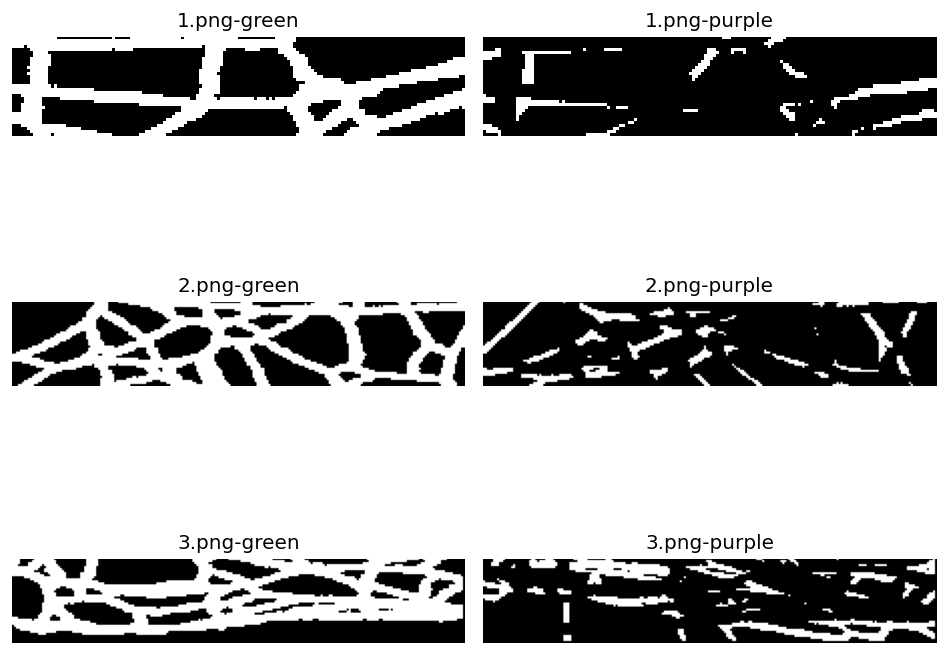

In [8]:
# Jupyter cell
%matplotlib inline
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

imgs = [Path(f'{i}.png') for i in (1,2,3)]

# HSV 阈值
HGL, HGU = ( 40, 60, 50), ( 90,255,255)   # green
HPL, HPU = (120,40, 50), (155,255,255)    # purple
S_W, V_W = 40, 200                        # white background

ratios, masks = [], []

for p in imgs:
    bgr = cv2.imread(str(p))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    bg = (hsv[:,:,1] < S_W) & (hsv[:,:,2] > V_W)
    fg = ~bg
    g = cv2.inRange(hsv, HGL, HGU).astype(bool) & fg
    pu = cv2.inRange(hsv, HPL, HPU).astype(bool) & fg

    g_cnt, p_cnt = g.sum(), pu.sum()
    ratios.append((p.name, p_cnt/g_cnt if g_cnt else np.inf))
    masks.append((g, pu))

for n,r in ratios:
    print(f'{n}: {r:.4f}')

rows, cols = len(masks), 2
fig, ax = plt.subplots(rows, cols, figsize=(4*cols,2.5*rows), squeeze=False)
for i,(g,pu) in enumerate(masks):
    ax[i,0].imshow(g*255, cmap='gray');  ax[i,0].set_title(f'{imgs[i].name}-green')
    ax[i,1].imshow(pu*255, cmap='gray'); ax[i,1].set_title(f'{imgs[i].name}-purple')
    for j in range(cols): ax[i,j].axis('off')
plt.tight_layout(); plt.show()